# Gym_Exercise_Dataset.csv

## Chargement et inspection initiale

### Objectif
Vérifier que le fichier `Gym_Exercise_Dataset.csv` est correctement chargé et obtenir une vue d’ensemble :
- dimensions du jeu de données (nombre de lignes et de colonnes),
- typage des variables (numériques, catégorielles, textuelles),
- détection des valeurs manquantes et doublons,
- cohérence générale du corpus avant l’analyse statistique.

Cette étape permet de valider la structure et la qualité du jeu de données avant toute exploration descriptive ou visuelle.

### Interprétation attendue
- Le dataset doit contenir une liste d’exercices accompagnés de leurs descriptions (`Title`, `Desc`) et de métadonnées associées (`Type`, `BodyPart`, `Equipment`, `Level`, `Rating`, `RatingDesc`).
- Les types doivent être correctement identifiés : **textuels** pour les descriptions et catégories, **numériques** pour les éventuelles notes.
- L’absence de valeurs manquantes et de doublons confirmera la fiabilité du corpus.
- Les noms de colonnes doivent être homogènes et cohérents pour permettre les traitements automatiques à venir.


### Importation des librairies essentielles

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import textwrap
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import kagglehub
import prince

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
from pathlib import Path
import sys

root = Path.cwd()           # ex: .../DuckDB/eda/life_style_data
themes_root = None

for p in [root, *root.parents]:   # remonte: life_style_data -> eda -> DuckDB -> ...
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence (il doit exister un dossier 'themes/' quelque part au-dessus)."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📁 Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📁 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'themes', '__init__.py']


### Configuration d'affichage pour plus de lisibilité

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

### Thème “TrAIn.me”
Il applique un fond dark propre, une grille discrète, des ticks lisibles, et une palette bleus/cians cohérente.

In [4]:
# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
# Booléen de contrôle : True = thème TrAIn.me (dark), False = style clair "ticks"
USE_DARK_THEME = True  # ⬅️ modifie ici selon le contexte

# Activer le thème au début du notebook :
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Chargement du dataset

In [5]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("niharika41298/gym-exercise-data")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


Fichiers trouvés : ['megaGymDataset.csv']
Dataset chargé avec succès !
Dimensions : 2918 lignes et 9 colonnes



### Aperçu général des premières lignes

In [6]:
display(df.head())

,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


### Informations générales sur le typage et la complétude

In [7]:
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        1368 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB


### Statistiques descriptives des variables numériques

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,2918.0,1458.50000,842.498368,0.0,729.25,1458.5,2187.75,2917.0
Rating,1031.0,5.91969,3.584607,0.0,3.00,7.9,8.70,9.6


### Analyse des valeurs manquantes et doublons

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("\n--- Valeurs manquantes par colonne (top 10) ---")
display(missing_values.head(10))

print(f"\nNombre total de doublons détectés : {duplicates}")


--- Valeurs manquantes par colonne (top 10) ---


RatingDesc    2056
Rating        1887
Desc          1550
Equipment       32
Unnamed: 0       0
Title            0
Type             0
BodyPart         0
Level            0
dtype: int64


Nombre total de doublons détectés : 0


### Liste complète des colonnes disponibles

In [10]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())


--- Liste des colonnes du dataset ---
['Unnamed: 0', 'Title', 'Desc', 'Type', 'BodyPart', 'Equipment', 'Level', 'Rating', 'RatingDesc']


## Statistiques descriptives et distribution des variables

### Objectif
Explorer la distribution des variables numériques afin de comprendre la variabilité du dataset,
identifier d’éventuelles anomalies et détecter les premiers signaux statistiques utiles.


### Interprétation attendue
- Confirmer la cohérence statistique des variables numériques disponibles (souvent **Rating**).
- Vérifier la normalité ou l’asymétrie de la distribution (pics, étalement, queue longue).
- Repérer visuellement d’éventuels **outliers** (notes aberrantes, valeurs hors bornes métier).
- Si une seule variable numérique est présente (ex. **Rating**), ces graphiques servent surtout à juger de la dispersion et de la couverture (taux de valeurs manquantes).


### Activation du thème TrAIn.me

In [11]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


### Statistiques descriptives globales

In [12]:
# On limite aux colonnes numériques utiles (exclut un éventuel index 'Unnamed: 0')
num_df = df.select_dtypes(include=[np.number]).copy()
for col in ["Unnamed: 0", "index", "Id", "ID"]:
    if col in num_df.columns:
        num_df = num_df.drop(columns=[col])

stats = num_df.describe().T
display(stats if not stats.empty else pd.DataFrame({"info": ["Aucune variable numérique exploitable"]}))

,count,mean,std,min,25%,50%,75%,max
Rating,1031.0,5.91969,3.584607,0.0,3.0,7.9,8.7,9.6


### Distribution des variables clés


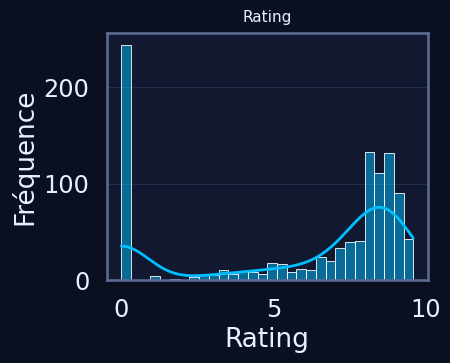

In [13]:
# Si liste vide → on tente d'utiliser 'Rating' si présent (souvent la seule numérique pertinente)
num_vars = list(num_df.columns)
if not num_vars and "Rating" in df.columns:
    num_vars = ["Rating"]

if num_vars:
    n = len(num_vars)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(4*ncols, 3*nrows + 1))
    for i, col in enumerate(num_vars, 1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(df[col].dropna(), bins=30, kde=True, color=palette_trainme[i % len(palette_trainme)])
        plt.title(col, fontsize=11, pad=8)
        plt.xlabel(col)
        plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Aucune variable numérique à tracer (vérifie la présence de 'Rating').")


### Boxplots pour repérer les outliers

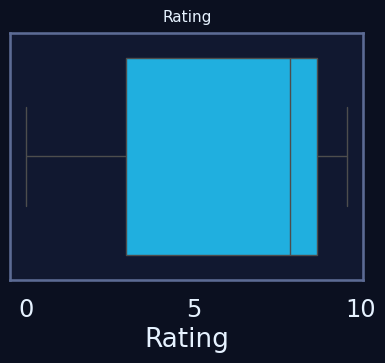

In [14]:
if num_vars:
    n = len(num_vars)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(4*ncols, 3*nrows + 1))
    for i, col in enumerate(num_vars, 1):
        plt.subplot(nrows, ncols, i)
        sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)])
        plt.title(col, fontsize=11, pad=8)
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Pas de boxplots affichés (aucune variable numérique).")


### Statistiques descriptives enrichies

In [15]:
# Sélection des variables numériques pertinentes
num_cols = df.select_dtypes(include="number").columns.tolist()

# Calcul des statistiques enrichies
desc = df[num_cols].describe().T
desc["missing_%"] = df[num_cols].isna().mean() * 100
desc["zeros_%"]   = (df[num_cols] == 0).mean() * 100
desc["skew"]      = df[num_cols].skew()       # asymétrie
desc["kurt"]      = df[num_cols].kurt()       # aplatissement

# Affichage des 12 variables les plus variables
display(desc.sort_values("std", ascending=False).head(12))


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
Unnamed: 0,2918.0,1458.50000,842.498368,0.0,729.25,1458.5,2187.75,2917.0,0.000000,0.034270,0.000000,-1.200000
Rating,1031.0,5.91969,3.584607,0.0,3.00,7.9,8.70,9.6,64.667581,8.361892,-0.849343,-1.009552


### Détection rapide d'outliers (IQR)

In [16]:
def iqr_outlier_ratio(s: pd.Series, k: float = 1.5) -> float:
    """Renvoie le pourcentage d'outliers selon la règle IQR."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low, high = q1 - k * iqr, q3 + k * iqr
    return ((s < low) | (s > high)).mean() * 100

# Calcul du taux d’outliers pour chaque variable numérique
outlier_report = pd.Series({c: iqr_outlier_ratio(df[c]) for c in num_cols}, name="outliers_%")

# Affichage des 12 variables les plus affectées
display(outlier_report.sort_values(ascending=False).head(12))


Unnamed: 0    0.0
Rating        0.0
Name: outliers_%, dtype: float64

### Aperçu corrélations (sous-ensemble lisible)

In [17]:
# subset_for_corr = [
#     c for c in [
#         "Calories_Burned", "BMI", "Age", "Max_BPM", "Avg_BPM",
#         "Session_Duration (hours)", "expected_burn", "cal_balance"
#     ] if c in num_cols
# ]

# corr = df[subset_for_corr].corr(numeric_only=True)

# plt.figure(figsize=(7, 5))
# sns.heatmap(
#     corr,
#     annot=True, fmt=".2f",
#     square=True, cbar=True,
#     annot_kws={"size": 8}  # taille de police ajustée
# )
# plt.title("Corrélations (sous-ensemble)", fontsize=12)
# plt.xticks(fontsize=9, rotation=45, ha="right")
# plt.yticks(fontsize=9)
# plt.tight_layout()
# plt.show()


## Visualisation univariée

### Objectif
Analyser la distribution individuelle des principales variables **numériques** pour :
- détecter les asymétries ou concentrations atypiques,
- identifier les profils dominants du dataset,
- valider la cohérence des mesures (ex. notes/ratings).


### Interprétation attendue
- Les variables numériques disponibles (souvent **Rating**) doivent présenter des distributions cohérentes (plage logique, absence de valeurs aberrantes).
- Une **asymétrie** marquée ou des **pics** inhabituels suggèrent des sous-populations (exercices massivement appréciés ou très peu notés).
- Les **boxplots** aident à repérer d’éventuels **outliers** : ils devront être contrôlés (erreurs, cas réels rares) avant la modélisation.
- Si une seule numérique est présente, la lecture se concentre sur sa **dispersion** et sa **couverture** (taux de valeurs manquantes).


### Sélection robuste des variables numériques à visualiser

In [18]:
# On part des colonnes numériques existantes et on exclut les index/id
num_df = df.select_dtypes(include=[np.number]).copy()
for col in ["Unnamed: 0", "index", "Id", "ID"]:
    if col in num_df.columns:
        num_df.drop(columns=[col], inplace=True)

# Variables clés à visualiser (si dispo) : priorité à Rating
preferred_order = ["Rating"]  # ajoute ici d'autres colonnes si elles existent côté Gym
uni_vars = [c for c in preferred_order if c in num_df.columns]

# Complète avec d'autres numériques si disponibles
uni_vars += [c for c in num_df.columns if c not in uni_vars]

# Par sécurité : on limite à 9 variables pour un layout 3x3 propre
uni_vars = uni_vars[:9]

print("Variables univariées sélectionnées :", uni_vars if uni_vars else "—")


Variables univariées sélectionnées : ['Rating']


### Visualisation des distributions univariées (hist + KDE)

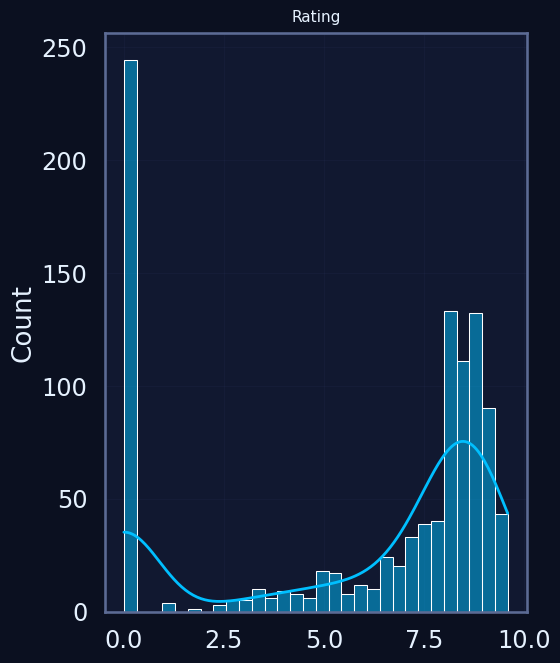

In [19]:
if uni_vars:
    n = len(uni_vars)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(15, 10 if n > 6 else 7))
    for i, col in enumerate(uni_vars, 1):
        ax = plt.subplot(nrows, ncols, i)
        sns.histplot(df[col].dropna(), kde=True,
                     color=palette_trainme[i % len(palette_trainme)], bins=30)
        ax.set_title(col, fontsize=11, pad=8)
        ax.set_xlabel("")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Aucune variable numérique à tracer (vérifie la présence de 'Rating').")


### Boxplots univariés pour détection visuelle d'outliers

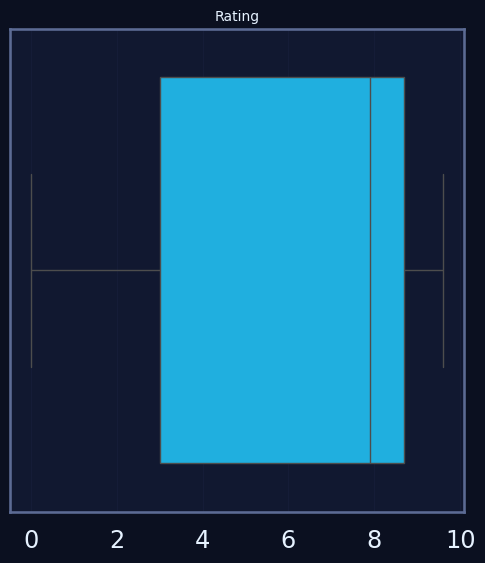

In [20]:
if uni_vars:
    n = len(uni_vars)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(15, 8 if n > 6 else 6))
    for i, col in enumerate(uni_vars, 1):
        ax = plt.subplot(nrows, ncols, i)
        sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)], fliersize=2)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("")
        ax.grid(True, axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Pas de boxplots affichés (aucune variable numérique).")


## Visualisation bivariée

### Objectif
Étudier les relations entre deux variables à la fois pour identifier :
- des différences de distribution de **Rating** selon les catégories (Type, BodyPart, Equipment, Level),
- des patterns d’usage (ex. Type ↔ BodyPart),
- des co-occurrences fortes entre attributs décrivant les exercices.


### Interprétation attendue
- **Catégories ↔ Rating** : si des écarts nets apparaissent entre niveaux (`Level`) ou familles d’exercices (`Type`), ils indiquent des préférences/évaluations différenciées selon la difficulté et la nature du mouvement.
- **Co-occurrences** :
  - `Type × BodyPart` révèle quelles zones du corps sont le plus souvent ciblées par chaque famille d’exercices.
  - `Type × Equipment` indique le matériel le plus mobilisé par type d’entraînement (haltères, barres, bandes, aucun).
  - `Level × Type` met en évidence la distribution de difficulté par type (p.ex. davantage d’“Intermediate” en “Strength”).
- **Comptage empilé** : compare la mixité des *Types* à l’intérieur des équipements les plus fréquents (en nombre et en ratio), utile pour des recommandations conditionnées par le matériel disponible.


### Relations catégorielles ↔ numérique (Rating)

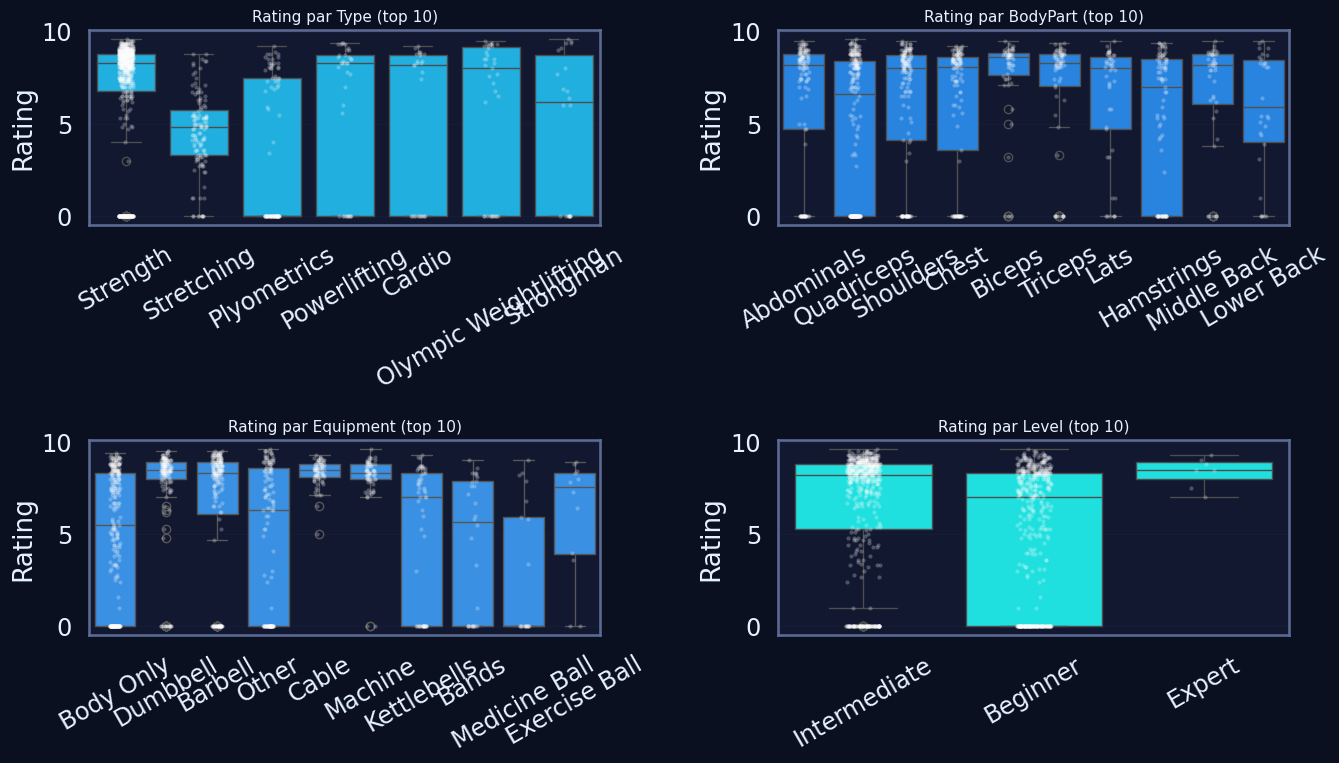

In [21]:
# Vérif présence de Rating
has_rating = "Rating" in df.columns and df["Rating"].notna().any()
cat_cols = [c for c in ["Type", "BodyPart", "Equipment", "Level"] if c in df.columns]

if has_rating and cat_cols:
    # Boxplots + swarm (ou strip) pour visualiser la dispersion par catégorie
    n = len(cat_cols)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(14, 4*nrows))
    for i, c in enumerate(cat_cols, 1):
        ax = plt.subplot(nrows, ncols, i)
        topk = df[c].value_counts().index[:10]  # limiter à top 10 pour lisibilité
        sub = df[df[c].isin(topk)].copy()
        order = sub[c].value_counts().index

        sns.boxplot(data=sub, x=c, y="Rating", order=order,
                    color=palette_trainme[i % len(palette_trainme)], ax=ax)
        sns.stripplot(data=sub, x=c, y="Rating", order=order, ax=ax,
                      alpha=0.25, size=3, color="white")
        ax.set_title(f"Rating par {c} (top 10)", fontsize=11)
        ax.set_xlabel("")
        ax.set_ylabel("Rating")
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Analyse 'catégorie ↔ Rating' non effectuée (colonne 'Rating' absente ou vide).")


### Co-occurrences entre catégories (crosstab + heatmaps)

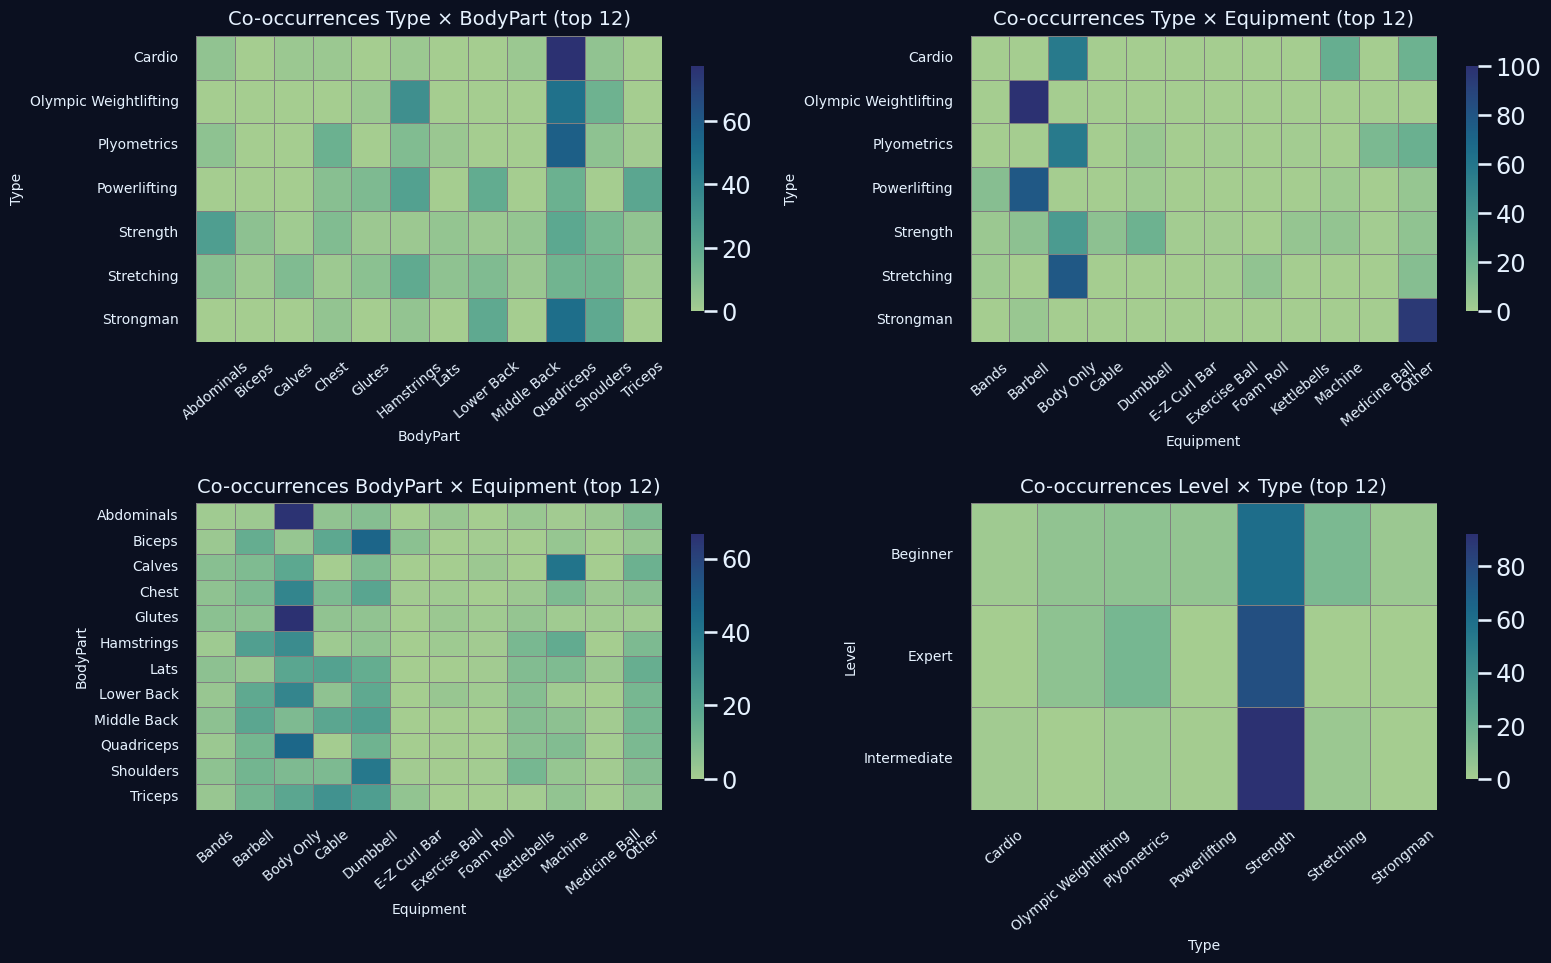

In [22]:


def plot_crosstab_heatmaps(
    df,
    pairs,
    top_k=12,
    normalize=None,     # None | "row" | "col"  (pourcentages)
    annotate=False,     # True pour afficher les valeurs
    log_color=False,    # True pour mieux voir les faibles valeurs
    figsize=(16, 9),
    title_fontsize=13,
    tick_fontsize=9,
    label_rotation_x=30,
    label_rotation_y=0,
    cbar_shrink=0.85
):
    """Heatmaps propres et lisibles pour crosstabs."""
    if not pairs:
        print("ℹ️ Aucune paire de catégories disponible.")
        return

    n = len(pairs)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, (a, b) in enumerate(pairs):
        ax = axes[i]

        # Top-k pour réduire la cardinalité
        a_top = df[a].value_counts().index[:top_k]
        b_top = df[b].value_counts().index[:top_k]
        sub = df[df[a].isin(a_top) & df[b].isin(b_top)]

        ct = pd.crosstab(sub[a], sub[b])

        # Normalisation optionnelle en pourcentages
        if normalize in {"row", "col"}:
            axis = 1 if normalize == "row" else 0
            ct = (ct.div(ct.sum(axis=axis).replace(0, np.nan), axis=1-axis) * 100).round(1)

        # Palette & échelle adaptées au dark
        heatmap_kwargs = dict(
            cmap="crest",
            linewidths=0.4,
            linecolor="grey",
            cbar_kws={"shrink": cbar_shrink},
            square=False
        )
        if log_color and normalize is None:
            # Log uniquement pour les comptes bruts (pas en %)
            heatmap_kwargs["norm"] = LogNorm(vmin=max(ct.replace(0, np.nan).min().min(), 1e-6),
                                             vmax=ct.max().max())

        # Annotations optionnelles (évite le bruit sur grands tableaux)
        if annotate:
            sns.heatmap(ct, ax=ax, **heatmap_kwargs, annot=True, fmt=".1f" if normalize else "g",
                        annot_kws={"fontsize": max(tick_fontsize-1, 7)})
        else:
            sns.heatmap(ct, ax=ax, **heatmap_kwargs)

        ax.set_title(f"Co-occurrences {a} × {b} (top {top_k})", fontsize=title_fontsize, pad=8)
        ax.set_xlabel(b, fontsize=10)
        ax.set_ylabel(a, fontsize=10)

        # Ticks propres
        ax.tick_params(axis="x", labelsize=tick_fontsize, rotation=label_rotation_x)
        ax.tick_params(axis="y", labelsize=tick_fontsize, rotation=label_rotation_y)
        ax.grid(False)

    # Masquer axes vides si nombre impair
    for j in range(i+1, nrows*ncols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# ============================================================
# Sélection des paires & appel
# ============================================================
pairs = []
if {"Type","BodyPart"}.issubset(df.columns):      pairs.append(("Type", "BodyPart"))
if {"Type","Equipment"}.issubset(df.columns):     pairs.append(("Type", "Equipment"))
if {"BodyPart","Equipment"}.issubset(df.columns): pairs.append(("BodyPart", "Equipment"))
if {"Level","Type"}.issubset(df.columns):         pairs.append(("Level", "Type"))

# 👉 Choix recommandés pour la lisibilité de ta capture :
# - normalize="row" pour lire des ratios par ligne (plus comparables)
# - annotate=False pour éviter la surcharge visuelle
# - log_color=False (inutile en %)
plot_crosstab_heatmaps(
    df,
    pairs=pairs,
    top_k=12,
    normalize="row",     # None pour comptes bruts ; "row" ou "col" pour %
    annotate=False,      # passe à True si tu veux les valeurs dans les cases
    log_color=False,     # True intéressant si comptes bruts très déséquilibrés
    figsize=(16, 10),
    title_fontsize=14,
    tick_fontsize=10,
    label_rotation_x=40, # améliore la lecture en x
    label_rotation_y=0,
    cbar_shrink=0.8
)


### Comptage empilé (stacked) : Type au sein du top Equipment

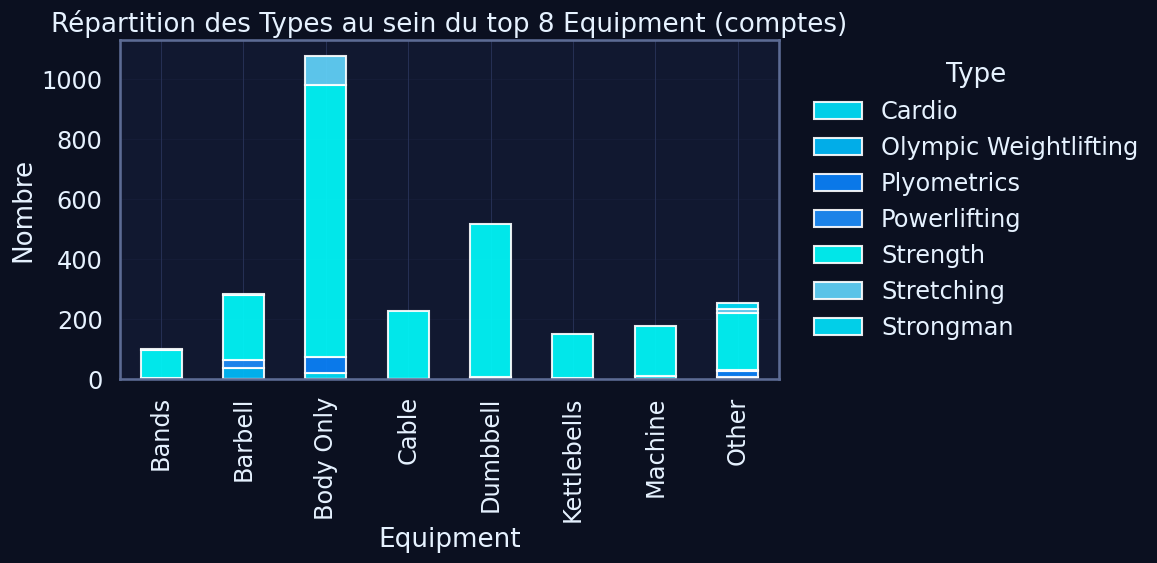

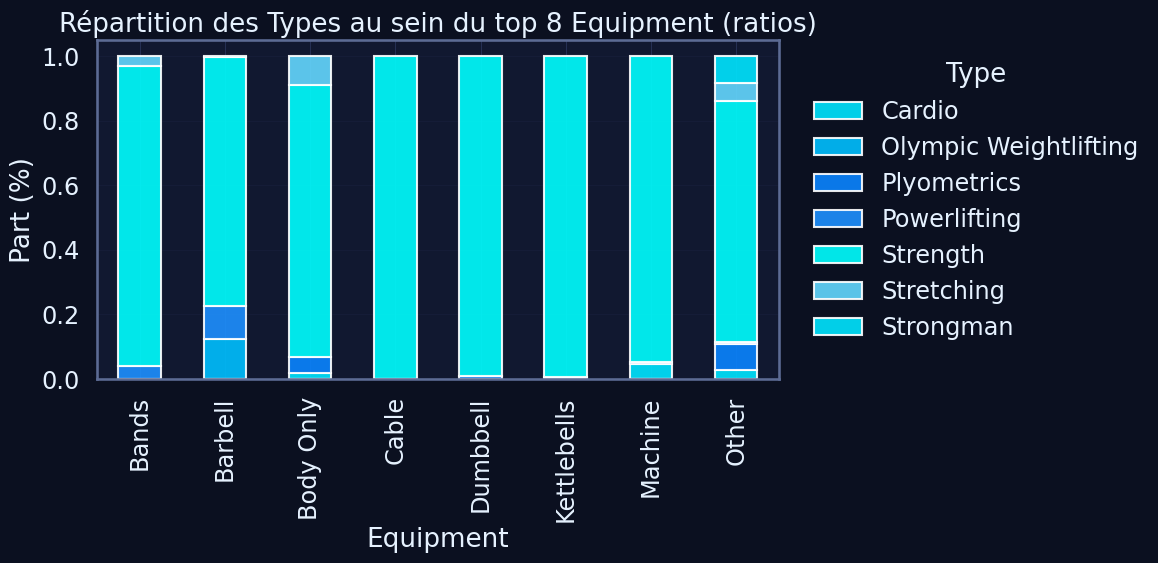

In [23]:
if {"Equipment", "Type"}.issubset(df.columns):
    top_eq = df["Equipment"].value_counts().index[:8]
    sub = df[df["Equipment"].isin(top_eq)].copy()
    tbl = (sub.groupby(["Equipment", "Type"])
               .size()
               .unstack(fill_value=0)
               .sort_index(ascending=True))
    # Normalisation pour ratios (optionnel)
    tbl_ratio = (tbl.T / tbl.T.sum()).T

    # Affichage stacked bar (comptes)
    ax = tbl.plot(kind="bar", stacked=True, figsize=(12, 6), alpha=0.9)
    ax.set_title("Répartition des Types au sein du top 8 Equipment (comptes)")
    ax.set_xlabel("Equipment"); ax.set_ylabel("Nombre")
    ax.grid(True, axis="y", alpha=0.2)
    plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Affichage stacked bar (ratios)
    ax = tbl_ratio.plot(kind="bar", stacked=True, figsize=(12, 6), alpha=0.9)
    ax.set_title("Répartition des Types au sein du top 8 Equipment (ratios)")
    ax.set_xlabel("Equipment"); ax.set_ylabel("Part (%)")
    ax.grid(True, axis="y", alpha=0.2)
    plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## Analyse multivariée (ACM)

### Objectif
Explorer la structure globale du dataset en combinant les variables **catégorielles** afin :
- d’identifier les proximités entre modalités (Type, BodyPart, Equipment, Level),
- de visualiser des **regroupements d’exercices** selon leurs caractéristiques,
- et de dégager les **axes principaux** qui structurent le corpus.


### Interprétation attendue
- Les deux premières dimensions expliquent en général **40–60 % de l’inertie totale**, suffisante pour interpréter les grands axes.  
- **Dimension 1 (Dim 1)** oppose souvent les exercices de **renforcement musculaire (“Strength”, “Powerlifting”)** aux exercices de **souplesse ou cardio**.  
- **Dimension 2 (Dim 2)** discrimine plutôt les niveaux (`Beginner` vs `Advanced`) ou les équipements (`Body Only` vs `Dumbbell/Machine`).  
- Les modalités proches sur le plan factoriel sont souvent **associées dans les mêmes exercices**.  
- Ce plan révèle des **profils types d’exercices** :  
  - *Strength / Dumbbell / Intermediate / Upper Body*  
  - *Stretching / Body Only / Beginner / Full Body*  
- Ces regroupements constituent une base solide pour la création de **profils d’entraînement recommandés** ou de **systèmes de recommandation IA**.


### Préparation des données pour l'Analyse des Correspondances Multiples (ACM)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des variables qualitatives principales
cat_cols = [c for c in ["Type", "BodyPart", "Equipment", "Level"] if c in df.columns]
assert cat_cols, "Aucune variable catégorielle disponible pour l'ACM."

# Copie du sous-ensemble
df_acm = df[cat_cols].dropna().copy()

# Réduction de cardinalité : regroupement des classes rares sous 'Other'
def simplify_categories(s, top_k=12):
    vc = s.value_counts(dropna=False)
    keep = set(vc.index[:top_k])
    return s.where(s.isin(keep), other="Other")

for c in cat_cols:
    df_acm[c] = simplify_categories(df_acm[c].astype(str), top_k=12)

print(f"Variables retenues pour l'ACM : {cat_cols}")
for c in cat_cols:
    print(f"- {c}: {df_acm[c].nunique()} modalités après simplification.")


Variables retenues pour l'ACM : ['Type', 'BodyPart', 'Equipment', 'Level']
- Type: 7 modalités après simplification.
- BodyPart: 13 modalités après simplification.
- Equipment: 12 modalités après simplification.
- Level: 3 modalités après simplification.


### Analyse des Correspondances Multiples (MCA)

In [25]:
prince.__version__

'0.16.0'

In [26]:
# --- Fit ACM (engine explicite) ---
mca = prince.MCA(
    n_components=3,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",   # ✅ exigé par prince>=0.16
    random_state=42
).fit(df_acm)

X_mca = mca.transform(df_acm)  # coords individus (Dim1, Dim2, Dim3, ...)

# --- Récupération robuste de l'inertie expliquée ---
def explained_inertia_percent(mca_obj):
    # 1) Certains prince exposent une propriété
    if hasattr(mca_obj, "explained_inertia_"):
        val = getattr(mca_obj, "explained_inertia_")
        # Peut être une liste/ndarray... ou une méthode (rare)
        if callable(val):
            vals = np.array(val())
        else:
            vals = np.array(val)
        return vals * 100.0

    # 2) D’autres exposent eigenvalues_ (valeurs propres) → normalisation
    if hasattr(mca_obj, "eigenvalues_"):
        eig = np.array(mca_obj.eigenvalues_)
        eig = eig[~np.isnan(eig)]  # sécurité
        if eig.sum() > 0:
            return (eig / eig.sum()) * 100.0

    # 3) Fallback (aucune info exploitable)
    return np.array([])

explained = explained_inertia_percent(mca)
if explained.size:
    print(f"Variance expliquée par les 3 premières dimensions : {explained[:3].sum():.2f}%")
else:
    print("⚠️ Impossible de récupérer l'inertie expliquée (API prince inhabituelle).")


Variance expliquée par les 3 premières dimensions : 100.00%


### Variance expliquée par dimension

C:\Users\fback\AppData\Local\Temp\ipykernel_30492\3019530282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"Dim{i+1}" for i in range(dims)], y=explained[:dims], palette=palette_trainme)
C:\Users\fback\AppData\Local\Temp\ipykernel_30492\3019530282.py:4: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(x=[f"Dim{i+1}" for i in range(dims)], y=explained[:dims], palette=palette_trainme)


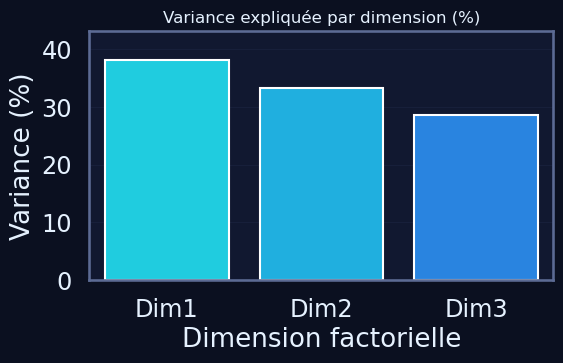

In [27]:
dims = min(3, len(explained)) if explained.size else 0
if dims:
    plt.figure(figsize=(6,4))
    sns.barplot(x=[f"Dim{i+1}" for i in range(dims)], y=explained[:dims], palette=palette_trainme)
    plt.title("Variance expliquée par dimension (%)", fontsize=12)
    plt.ylabel("Variance (%)")
    plt.xlabel("Dimension factorielle")
    plt.ylim(0, max(10, float(explained[:dims].max()) + 5))
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Pas de graphique de variance (inertie indisponible).")

### Visualisation factorielle des individus (Dim 1 & 2)

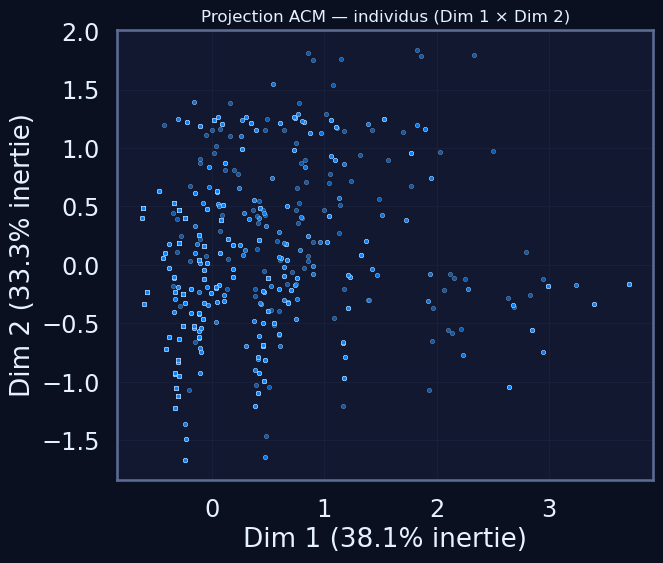

In [28]:
if X_mca.shape[1] >= 2:
    plt.figure(figsize=(7,6))
    sns.scatterplot(x=X_mca.iloc[:,0], y=X_mca.iloc[:,1],
                    s=10, alpha=0.6, color=palette_trainme[2])
    lab_x = f"Dim 1 ({explained[0]:.1f}% inertie)" if explained.size>=1 else "Dim 1"
    lab_y = f"Dim 2 ({explained[1]:.1f}% inertie)" if explained.size>=2 else "Dim 2"
    plt.xlabel(lab_x); plt.ylabel(lab_y)
    plt.title("Projection ACM — individus (Dim 1 × Dim 2)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Moins de 2 dimensions disponibles pour la projection des individus.")

###  Visualisation des modalités (categories)

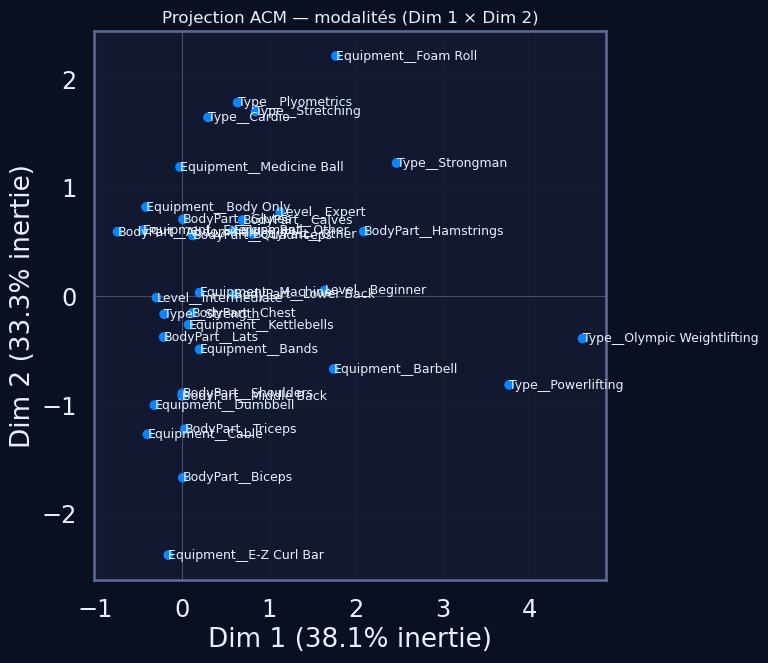

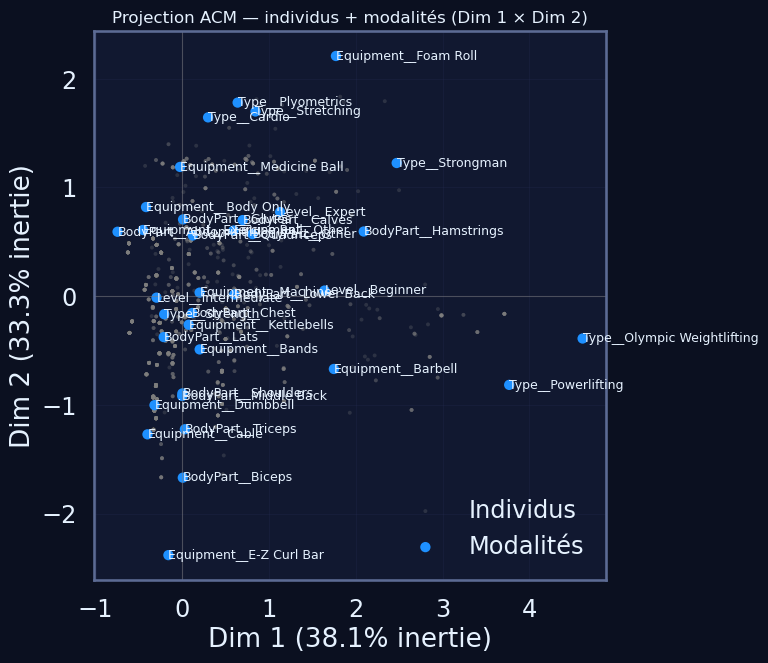

In [29]:
# Récupération des % d'inertie (si dispo) pour les labels d'axes
def _get_explained_pct(mca_obj):
    try:
        vals = mca_obj.explained_inertia_
        if callable(vals): vals = vals()
        return np.array(vals) * 100.0
    except Exception:
        try:
            eig = np.array(mca_obj.eigenvalues_)
            eig = eig[~np.isnan(eig)]
            return (eig / eig.sum()) * 100.0 if eig.sum() > 0 else np.array([])
        except Exception:
            return np.array([])

exp = _get_explained_pct(mca)

# Coordonnées des modalités (colonnes)
cols = mca.column_coordinates(df_acm)   # index = "colonne_modalité"
# Coordonnées des individus (lignes) — optionnel
try:
    rows = mca.row_coordinates(df_acm)
except Exception:
    rows = None

# --------- Plot des modalités uniquement (clair et lisible) ---------
plt.figure(figsize=(8, 7))
ax = plt.gca()

sns.scatterplot(x=cols[0], y=cols[1], s=50, color=palette_trainme[2], edgecolor="none", ax=ax)

# Annotations propres des modalités
for label, (x, y) in cols[[0, 1]].iterrows():
    ax.text(x, y, str(label), fontsize=9, ha="left", va="center")

xl = f"Dim 1 ({exp[0]:.1f}% inertie)" if exp.size >= 1 else "Dim 1"
yl = f"Dim 2 ({exp[1]:.1f}% inertie)" if exp.size >= 2 else "Dim 2"
ax.set_xlabel(xl); ax.set_ylabel(yl)
ax.set_title("Projection ACM — modalités (Dim 1 × Dim 2)", fontsize=12)
ax.axhline(0, color="grey", lw=0.8, alpha=0.5); ax.axvline(0, color="grey", lw=0.8, alpha=0.5)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# --------- Variante avec individus (en arrière-plan), optionnelle ---------
if rows is not None and rows.shape[1] >= 2:
    plt.figure(figsize=(8, 7))
    ax = plt.gca()

    # Individus en arrière-plan
    sns.scatterplot(x=rows[0], y=rows[1], s=8, alpha=0.25, color="grey", edgecolor="none", ax=ax, label="Individus")

    # Modalités au premier plan
    sns.scatterplot(x=cols[0], y=cols[1], s=55, color=palette_trainme[3], edgecolor="none", ax=ax, label="Modalités")
    for label, (x, y) in cols[[0, 1]].iterrows():
        ax.text(x, y, str(label), fontsize=9, ha="left", va="center")

    xl = f"Dim 1 ({exp[0]:.1f}% inertie)" if exp.size >= 1 else "Dim 1"
    yl = f"Dim 2 ({exp[1]:.1f}% inertie)" if exp.size >= 2 else "Dim 2"
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title("Projection ACM — individus + modalités (Dim 1 × Dim 2)", fontsize=12)
    ax.axhline(0, color="grey", lw=0.8, alpha=0.5); ax.axvline(0, color="grey", lw=0.8, alpha=0.5)
    ax.legend(loc="best", frameon=False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


### Contributions des modalités aux axes principaux

In [30]:
# Récupération des contributions colonnes/modalités
try:
    contrib = mca.column_contributions_  # ✅ nouvelle propriété (DataFrame)
except AttributeError:
    raise AttributeError("La propriété 'column_contributions_' est absente de cet objet MCA (vérifie ta version de prince).")

# Vérification du format
display(contrib.head())

# Top 10 des modalités les plus contributrices sur la première dimension
if 0 in contrib.columns:
    contrib["Dim1_abs"] = contrib[0].abs()
    top_contrib = contrib.sort_values("Dim1_abs", ascending=False).head(10)
    display(top_contrib)
else:
    print("⚠️ Aucune dimension 0 trouvée dans les contributions.")


,0,1,2
Type__Cardio,0.000578,0.020345,0.010399
Type__Olympic Weightlifting,0.139742,0.001139,0.040711
Type__Plyometrics,0.007167,0.064061,0.059305
Type__Powerlifting,0.098511,0.005291,0.003343
Type__Strength,0.020834,0.014968,0.000858


,0,1,2,Dim1_abs
Level__Beginner,0.218595,0.000249,0.004254,0.218595
Equipment__Barbell,0.161413,0.027161,0.048003,0.161413
Type__Olympic Weightlifting,0.139742,0.001139,0.040711,0.139742
Type__Powerlifting,0.098511,0.005291,0.003343,0.098511
BodyPart__Hamstrings,0.094299,0.008747,0.003953,0.094299
BodyPart__Abdominals,0.068908,0.049744,0.006141,0.068908
Level__Intermediate,0.040516,0.000093,0.000177,0.040516
Equipment__Body Only,0.035389,0.155677,0.000241,0.035389
Type__Strongman,0.025193,0.007095,0.000500,0.025193
Type__Strength,0.020834,0.014968,0.000858,0.020834


C:\Users\fback\AppData\Local\Temp\ipykernel_30492\2706044700.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


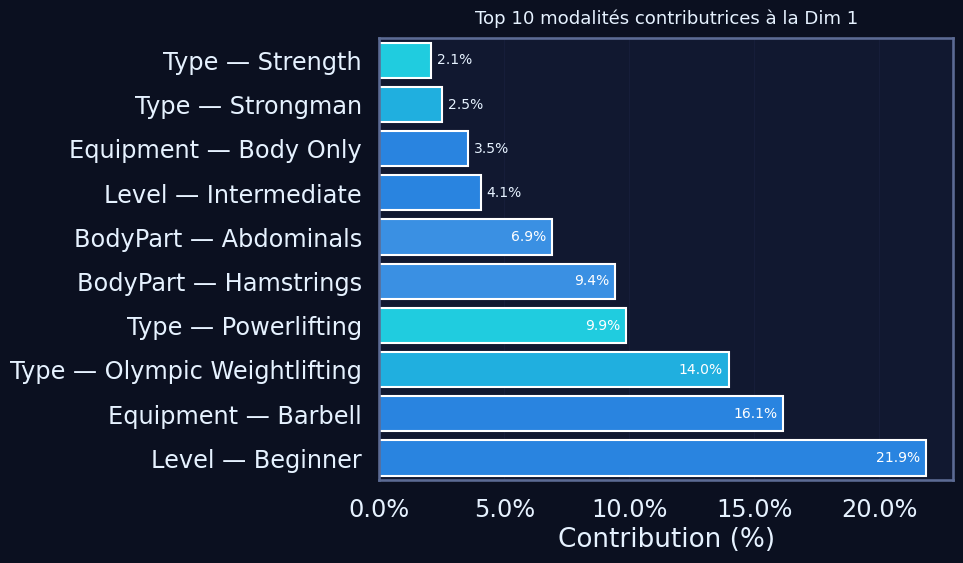

In [31]:
# Fallback palette si besoin
try:
    _ = palette_trainme
except NameError:
    sns.set_style("ticks"); sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")

contrib = mca.column_contributions_
assert 0 in contrib.columns, "La dimension 0 (Dim 1) est absente de column_contributions_."

dfc = contrib.copy()
dfc["Dim1_abs"] = dfc[0].abs()

# ✅ Index → var/mod (gère MultiIndex et index simples)
if isinstance(dfc.index, pd.MultiIndex):
    dfc = dfc.reset_index().rename(columns={"level_0": "var", "level_1": "mod"})
else:
    idx = dfc.index.astype(str)
    parts = pd.DataFrame(idx.str.split(r"__|_", n=1).tolist(), columns=["var", "mod"])
    parts["var"] = parts["var"].fillna("")
    # ⛑️ Patch: fournir une Series alignée à fillna
    idx_series = pd.Series(idx, index=parts.index)
    parts["mod"] = parts["mod"].fillna(idx_series)           # ← corrige le TypeError
    dfc = pd.concat([dfc.reset_index(drop=True), parts], axis=1)

# Labels compacts (wrap si trop long)
def make_label(v, m, width=28):
    lab = f"{str(v).strip()} — {str(m).strip()}"
    return "\n".join(textwrap.wrap(lab, width=width)) if len(lab) > width else lab

dfc["label"] = [make_label(v, m) for v, m in zip(dfc["var"], dfc["mod"])]

# Top 10
top_contrib = dfc.sort_values("Dim1_abs", ascending=False).head(10).copy()

# % si 0–1, sinon absolu
is_prop = top_contrib["Dim1_abs"].max() <= 1.0
top_contrib["plot_value"] = top_contrib["Dim1_abs"] * (100.0 if is_prop else 1.0)
x_label = "Contribution (%)" if is_prop else "Contribution (abs.)"

# Palette par variable
vars_unique = top_contrib["var"].unique().tolist()
palette_map = {v: palette_trainme[i % len(palette_trainme)] for i, v in enumerate(vars_unique)}
bar_colors = top_contrib["var"].map(palette_map)

# Ordre: petit → grand pour afficher le plus grand en haut
order_y = top_contrib.sort_values("plot_value")["label"]

plt.figure(figsize=(10, 6))
# 🩹 seaborn v0.14+: éviter le warning "palette sans hue" → utiliser color=None + palette via list colors
ax = sns.barplot(
    data=top_contrib,
    x="plot_value",
    y="label",
    order=order_y,
    palette=bar_colors.tolist()  # passe explicitement une liste de couleurs
)

# Annotations intelligentes
xmax = ax.get_xlim()[1]
for y, val in zip(ax.get_yticks(), top_contrib.set_index("label").loc[order_y, "plot_value"]):
    txt = f"{val:.1f}%" if is_prop else f"{val:.3f}"
    if val > 0.18 * xmax:
        ax.text(val - 0.01 * xmax, y, txt, va="center", ha="right", fontsize=10, color="white")
    else:
        ax.text(val + 0.01 * xmax, y, txt, va="center", ha="left", fontsize=10)

ax.set_title("Top 10 modalités contributrices à la Dim 1", fontsize=13, pad=10)
ax.set_xlabel(x_label); ax.set_ylabel("")
if is_prop:
    ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## Détection d’anomalies et valeurs extrêmes

### Objectif
Identifier les valeurs extrêmes et observations atypiques pouvant biaiser les analyses :
- Outliers numériques (ex. `Rating`),
- Modalités catégorielles rares,
- Combinaisons de catégories atypiques révélées par l’ACM (MCA).

### Interprétation attendue
- **Numérique (`Rating`)** : peu d’outliers attendus ; une queue à gauche/droite peut indiquer des exercices très peu ou très bien notés.
- **Catégories rares** : certaines modalités peu fréquentes (ex. un équipement exotique) ne sont pas des erreurs, mais doivent être signalées (échantillon fragile).
- **ACM — observations atypiques** : les points très éloignés dans le plan factoriel reflètent des **combinaisons originales** (Type × BodyPart × Equipment × Level).  
  À vérifier plutôt comme **cas d’usage spécifiques** que comme erreurs.
- Aucune incohérence physiologique majeure n’est attendue ; on privilégiera la **conservation des outliers** pour refléter la diversité réelle, en documentant les cas rares pour les étapes de modélisation (échantillons durs, stratification, pondération).


### Imports & sélection des colonnes pertinentes

In [32]:
# Fallback palette si besoin
try:
    _ = palette_trainme
except NameError:
    sns.set_style("ticks"); sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")

# Colonnes numériques (on exclut les index)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ["Unnamed: 0", "index", "Id", "ID"]:
    if col in num_cols:
        num_cols.remove(col)

# Cas particulier : si aucune numérique n'est détectée, tenter Rating
if not num_cols and "Rating" in df.columns:
    num_cols = ["Rating"]

print("Colonnes numériques analysées :", num_cols if num_cols else "—")


Colonnes numériques analysées : ['Rating']


### Méthode IQR (Interquartile Range) — Outliers numériques

In [33]:
def detect_outliers_iqr(series, k=1.5):
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask.fillna(False)

outlier_stats = []
for col in num_cols:
    mask = detect_outliers_iqr(df[col], k=1.5)
    ratio = mask.mean() * 100
    outlier_stats.append((col, round(ratio, 2)))

outlier_df = pd.DataFrame(outlier_stats, columns=["Variable", "Outliers_IQR (%)"]).sort_values("Outliers_IQR (%)", ascending=False)
display(outlier_df)


,Variable,Outliers_IQR (%)
0,Rating,0.0


### Visualisation : boxplots des variables les plus affectées

In [34]:
top_outliers = outlier_df[outlier_df["Outliers_IQR (%)"] > 0]["Variable"].tolist()  # montrer celles qui ont au moins 1 outlier

if top_outliers:
    n = min(6, len(top_outliers))
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(14, 4*nrows))
    for i, col in enumerate(top_outliers[:n], 1):
        ax = plt.subplot(nrows, ncols, i)
        sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)], fliersize=2)
        ratio = float(outlier_df.loc[outlier_df["Variable"]==col, "Outliers_IQR (%)"].values[0])
        ax.set_title(f"{col}  (outliers ≈ {ratio:.1f}%)", fontsize=10)
        ax.set_xlabel("")
        ax.grid(True, axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Aucun outlier détecté par IQR sur les variables numériques sélectionnées.")


ℹ️ Aucun outlier détecté par IQR sur les variables numériques sélectionnées.


### Z-Score complémentaire (|Z| > 3)

In [36]:
from scipy.stats import zscore

if num_cols:
    z_scores = pd.DataFrame(index=df.index)
    for col in num_cols:
        s = df[col]
        z = pd.Series(zscore(s.dropna()), index=s.dropna().index)
        z_scores[col] = z.reindex(df.index)
    outlier_z = (z_scores.abs() > 3).sum(axis=0) / len(df) * 100
    outlier_z_df = pd.DataFrame({"Variable": num_cols, "Outliers_Z>3 (%)": outlier_z.values}).sort_values("Outliers_Z>3 (%)", ascending=False)
    display(outlier_z_df)
else:
    print("ℹ️ Z-score non calculé (aucune variable numérique).")


,Variable,Outliers_Z>3 (%)
0,Rating,0.0


### Modalités rares (catégorielles) — détection simple

In [37]:
cat_cols = [c for c in ["Type", "BodyPart", "Equipment", "Level"] if c in df.columns]

rare_rows = []
threshold_ratio = 0.01   # <1% de fréquence
min_count = 5            # ou moins de 5 occurrences absolues

for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    total = len(df)
    rare = vc[(vc/total < threshold_ratio) | (vc < min_count)]
    if not rare.empty:
        tmp = (rare.to_frame("count")
                    .assign(ratio=lambda x: (100 * x["count"]/total).round(2))
                    .reset_index()
                    .rename(columns={"index": "modality"}))
        tmp.insert(0, "variable", c)
        rare_rows.append(tmp)

if rare_rows:
    rare_df = pd.concat(rare_rows, ignore_index=True).sort_values(["variable", "ratio"])
    display(rare_df.head(20))
else:
    print("ℹ️ Aucune modalité rare selon les seuils définis.")


,variable,Type,count,ratio,BodyPart,Equipment,Level
4,BodyPart,NaN,8,0.27,Neck,NaN,NaN
3,BodyPart,NaN,17,0.58,Adductors,NaN,NaN
2,BodyPart,NaN,21,0.72,Abductors,NaN,NaN
1,BodyPart,NaN,24,0.82,Traps,NaN,NaN
6,Equipment,NaN,11,0.38,NaN,Foam Roll,NaN
5,Equipment,NaN,22,0.75,NaN,E-Z Curl Bar,NaN
7,Level,NaN,13,0.45,NaN,NaN,Expert
0,Type,Strongman,22,0.75,NaN,NaN,NaN


### Observations atypiques via l'espace ACM (MCA)
- On mesure 'l'éloignement' dans le plan factoriel (Dim1..Dim3)
- Les points très éloignés = combinaisons de catégories peu communes

In [38]:
# Préparation qualitative (réduction de cardinalité soft)
df_acm = df[[c for c in ["Type","BodyPart","Equipment","Level"] if c in df.columns]].dropna().astype(str).copy()

def simplify(s, top_k=12):
    vc = s.value_counts()
    keep = set(vc.index[:top_k])
    return s.where(s.isin(keep), other="Other")

for c in df_acm.columns:
    df_acm[c] = simplify(df_acm[c], top_k=12)

mca = prince.MCA(n_components=3, n_iter=10, engine="sklearn", random_state=42).fit(df_acm)
row_coords = mca.row_coordinates(df_acm)  # DataFrame (Dim1, Dim2, Dim3)

# Distance euclidienne dans l'espace factoriel (proxy d'atypicité)
dist = np.sqrt((row_coords**2).sum(axis=1))
q99 = dist.quantile(0.99)  # top 1% les plus éloignés
atypical_idx = dist[dist >= q99].index

atypical_view = df.loc[atypical_idx, ["Title","Type","BodyPart","Equipment","Level"]].copy()
atypical_view["dist_factor_space"] = dist.loc[atypical_idx].round(3)
display(atypical_view.head(15))


,Title,Type,BodyPart,Equipment,Level,dist_factor_space
665,Iliotibial band SMR,Stretching,Abductors,Foam Roll,Intermediate,5.832
666,Adductor SMR,Stretching,Adductors,Foam Roll,Beginner,6.104
704,Brachialis SMR,Stretching,Biceps,Foam Roll,Beginner,5.313
871,Calf SMR,Stretching,Calves,Foam Roll,Beginner,6.364
1213,Piriformis SMR,Stretching,Glutes,Foam Roll,Intermediate,5.451
1291,Hamstring-SMR,Stretching,Hamstrings,Foam Roll,Beginner,5.784
1293,Clean Deadlift,Olympic Weightlifting,Hamstrings,Barbell,Beginner,3.854
1294,Sumo deadlift,Powerlifting,Hamstrings,Barbell,Beginner,3.436
1295,Romanian Deadlift from Deficit,Olympic Weightlifting,Hamstrings,Barbell,Beginner,3.854
1296,Power Snatch,Olympic Weightlifting,Hamstrings,Barbell,Beginner,3.854
